# Student Info
# Chinese Name: Li Anran
# English Name: Yuki
# ID:C00292764

# Introduction

This project analyzes the Cardiovascular Disease Dataset from Kaggle, which contains 70,000 patient records with health indicators such as age, blood pressure, cholesterol level, glucose level, and lifestyle factors like smoking and alcohol intake.

Cardiovascular disease was chosen as the target variable because it is one of the leading causes of death worldwide. As a binary classification variable (0 = no disease, 1 = disease), it is well-suited for classification modeling and risk prediction tasks.

To accurately predict cardiovascular disease and identify key risk factors, we employed the Transformer model, which uses a self-attention mechanism to capture complex relationships between different health indicators simultaneously. The goal is to build an effective predictive model that can assist in early detection and provide insights into the key determinants of cardiovascular disease.

In [37]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization
from tensorflow.keras.layers import MultiHeadAttention, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/akshatshaw7/cardiovascular-disease-dataset/health_data.csv


# Exploring Data

In [38]:
df = pd.read_csv("/kaggle/input/datasets/akshatshaw7/cardiovascular-disease-dataset/health_data.csv")

This dataset contains 70,000 patient records for cardiovascular disease prediction, combining health examination data with lifestyle factors.

* id: representing the unique identifier for each patient.
* age: Float value of patient age (unit: days).
* gender: Integer code representing gender (1=women, 2=men).
* height: Float value of patient height (unit: cm).
* weight: Float value of patient weight (unit: kg).
* ap_hi: Float value of systolic blood pressure (unit: mmHg).
* ap_lo: Float value of diastolic blood pressure (unit: mmHg).
* cholesterol: Integer code for cholesterol level (1=normal, 2=above normal, 3=well above normal).
* gluc: Integer code for glucose level (1=normal, 2=above normal, 3=well above normal).
* smoke: Integer binary value indicating smoking status (0=non-smoker, 1=smoker).
* alco: Integer binary value indicating alcohol intake (0=non-drinker, 1=drinker).
* active: Integer binary value indicating physical activity (0=inactive, 1=active).
* cardio: Integer binary target variable indicating cardiovascular disease (0=no disease, 1=disease).

The dataset contains 5 float64 variables (age, height, weight, ap_hi, ap_lo) and 7 int64 variables (gender, cholesterol, gluc, smoke, alco, active, cardio).

In [39]:
df.head(5)

,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0.0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,1,1.0,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,2,2.0,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,3,3.0,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,4,4.0,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


No Missing Values

In [40]:
print(df.isnull().sum())
print(df.dtypes)

Unnamed: 0     0
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64
Unnamed: 0       int64
id             float64
age            float64
gender           int64
height         float64
weight         float64
ap_hi          float64
ap_lo          float64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object


The dataset contains 70,000 patient records with 14 columns. The target variable 'cardio' has a mean of 0.4997, indicating a balanced dataset. However, anomalies are detected in blood pressure readings: ap_hi and ap_lo contain negative values and extreme highs (up to 16,020 mmHg), which are medically impossible. These unrealistic values require data cleaning before modeling.

In [41]:
df.describe()

,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,34999.500000,49972.419900,19468.865814,0.349571,164.359229,74.205690,128.817286,96.630414,0.366871,0.226457,0.088129,0.053771,0.803729,0.499700
std,20207.403759,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,0.000000,10798.000000,0.000000,55.000000,10.000000,-150.000000,-70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17499.750000,25006.750000,17664.000000,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,34999.500000,50001.500000,19703.000000,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,52499.250000,74889.250000,21327.000000,1.000000,170.000000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,69999.000000,99999.000000,23713.000000,1.000000,250.000000,200.000000,16020.000000,11000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


# Data Cleaning

Records with negative blood pressure values were removed, as blood pressure cannot be negative in medical terms.

In [42]:
df = df[(df['ap_hi'] > 0) & (df['ap_lo'] > 0)]

Systolic blood pressure was restricted to the range of 80-300 mmHg, and diastolic blood pressure was restricted to 40-200 mmHg, which are medically reasonable ranges.

In [43]:
df = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 300)]
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 200)]

Age was converted from days to years by dividing by 365 for better interpretability.

In [44]:
df['age'] = df['age'] / 365
print(f"\nThe number of data after cleaning: {len(df)}")


The number of data after cleaning: 68758


# Target Value Distribution Analysis

The target variable 'cardio' has two classes: 0 (no cardiovascular disease) and 1 (cardiovascular disease). After cleaning, the dataset contains 68,758 records, with 34,722 healthy cases and 34,036 diseased cases. The proportion of positive cases is 49.50%, indicating a well-balanced dataset

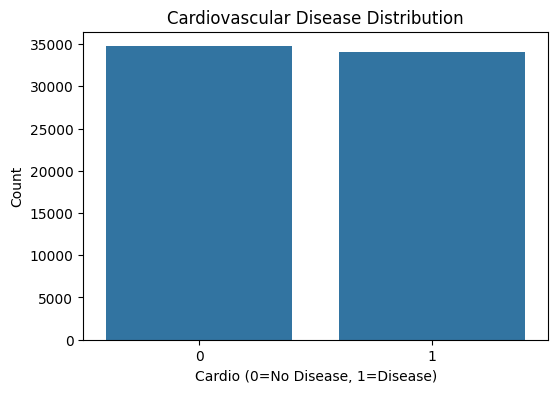

In [45]:
plt.figure(figsize=(6,4))
sns.countplot(x='cardio', data=df)
plt.title('Cardiovascular Disease Distribution')
plt.xlabel('Cardio (0=No Disease, 1=Disease)')
plt.ylabel('Count')
plt.show()

# Feature Distribution Visualization

* The age distribution shows a roughly normal pattern centered around 50-60 years, with most patients falling within the 40-65 year range. No extreme outliers are present.
* The height distribution peaks around 160-170cm, which is within the normal adult height range. The distribution appears roughly normal and reasonable.
* The weight distribution peaks around 70-75kg, showing a reasonable pattern for adult patients. A small number of extreme values exist, but these are within acceptable limits.
* Systolic blood pressure is concentrated around 120 mmHg, which is within the normal range. The distribution shows a slight right skew, with a small number of hypertensive cases extending to 240 mmHg.
* Diastolic blood pressure is concentrated around 80 mmHg, which is within the normal range. The distribution is roughly symmetric and clean, with no obvious anomalies.

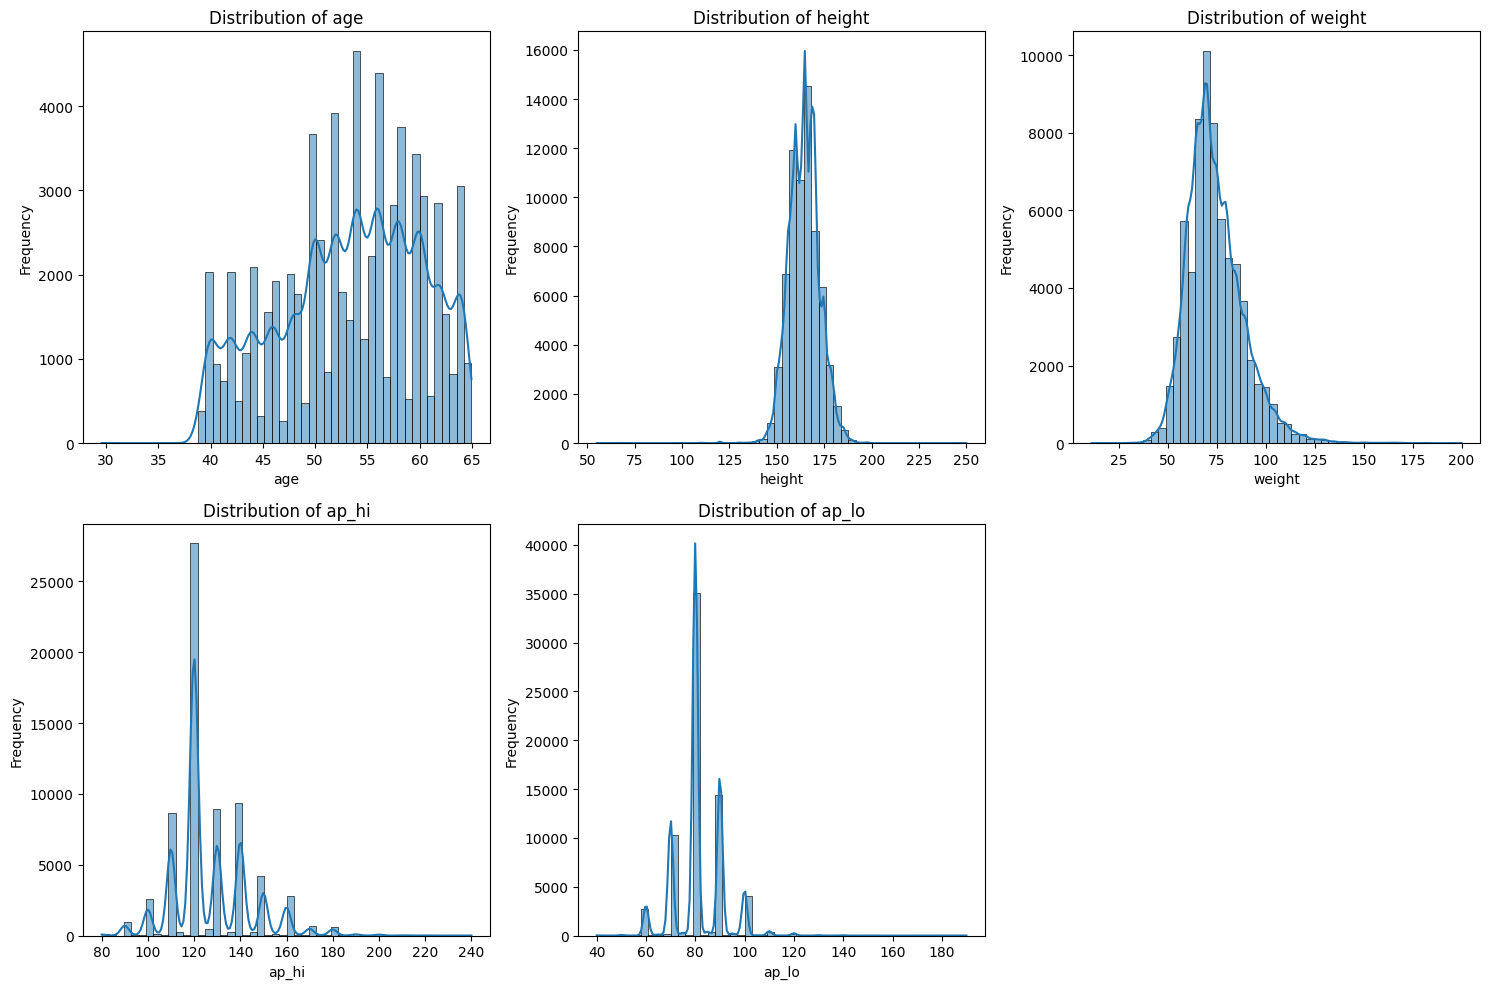

In [46]:
plt.figure(figsize=(15, 10))

num_features = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

for i, feature in enumerate(num_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[feature], bins=50, kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Data Standardization

Feature standardization was applied using StandardScaler, which transforms each feature to have zero mean and unit variance. This is critical for Transformer models as they are sensitive to input feature scales.

In [47]:
feature_cols = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 
                'cholesterol', 'gluc', 'smoke', 'alco', 'active']

X = df[feature_cols].values
y = df['cardio'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

The data was reshaped to 3D format required by Transformer: (samples, sequence length, features). Since each patient is an independent record, the sequence length was set to 1.

In [49]:
X_train_3d = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_3d = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

print(f"Format:{X_train_3d.shape}")

Format:(55006, 1, 11)


# Transformer Model

The Transformer model was chosen for this task because it can capture complex relationships between different health indicators simultaneously, rather than processing them one by one. The model uses a self-attention mechanism, which allows it to learn which features are most important for predicting cardiovascular disease. A dropout rate of 0.2 was added to prevent overfitting, ensuring the model generalizes well to new patients. The learning rate was set to 0.0005, which is relatively low, so the model learns slowly and steadily without making large jumps that could miss the best solution. Binary cross-entropy is used as the loss function because this is a yes/no prediction task (whether a patient has cardiovascular disease). 

In [50]:
tf.random.set_seed(42)

def build_transformer_classifier(input_shape, num_heads=4, key_dim=64, ff_dim=64, dropout_rate=0.2):
    inputs = Input(shape=input_shape)
    
    x = Dense(ff_dim, activation='relu')(inputs)
    
    attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
    x = LayerNormalization(epsilon=1e-6)(attention_output + x)
    
    x = GlobalAveragePooling1D()(x)
    
    x = Dense(32, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(16, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs, outputs)
    return model

input_shape = (X_train_3d.shape[1], X_train_3d.shape[2])
model = build_transformer_classifier(input_shape)

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 1, 11)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1, 64)     │        768 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 64)     │     66,368 │ dense_8[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 1, 64)     │          0 │ multi_head_atten… │
│                     │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 64)     │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 32)        │      2,080 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 32)        │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 16)        │        528 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 16)        │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │         17 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,889 (273.00 KB)

 Trainable params: 69,889 (273.00 KB)

 Non-trainable params: 0 (0.00 B)

The model was trained with 30% of the data used for validation. Early stopping was applied to halt training if validation loss did not improve for 10 consecutive epochs, preventing overfitting and saving time. The best weights were restored when training stopped.

In [51]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_3d, y_train,
    validation_split=0.3,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
602/602 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.6934 - loss: 0.5990 - val_accuracy: 0.7286 - val_loss: 0.5560
Epoch 2/100
602/602 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7274 - loss: 0.5629 - val_accuracy: 0.7289 - val_loss: 0.5532
Epoch 3/100
602/602 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7317 - loss: 0.5567 - val_accuracy: 0.7306 - val_loss: 0.5530
Epoch 4/100
602/602 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7309 - loss: 0.5538 - val_accuracy: 0.7295 - val_loss: 0.5523
Epoch 5/100
602/602 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7329 - loss: 0.5516 - val_accuracy: 0.7302 - val_loss: 0.5516
Epoch 6/100
602/602 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7337 - loss: 0.5504 - val_accuracy: 0.7313 - val_loss: 0.5516
Epoch 7/100
602/602 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7349 - loss: 0.5515 - val_accuracy: 0.7310 - val_loss: 0.5519
Epoch 8/100
602/602 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7367 - loss: 0.5487 - val_acc

The model achieved 73.22% accuracy and an AUC of 0.80 on the test set. The classification report shows balanced performance between both classes, with F1-scores of 0.75 for healthy patients and 0.72 for diseased patients.

In [52]:
y_pred_prob = model.predict(X_test_3d)
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc:.4f}")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.7322
AUC: 0.7991
              precision    recall  f1-score   support

  No Disease       0.72      0.78      0.75      6945
     Disease       0.75      0.69      0.72      6807

    accuracy                           0.73     13752
   macro avg       0.73      0.73      0.73     13752
weighted avg       0.73      0.73      0.73     13752



The confusion matrix shows the model correctly identified 5,390 healthy patients and 4,679 diseased patients, with 1,555 false positives and 2,128 false negatives. Overall, the model demonstrates balanced performance with a slight advantage in identifying healthy individuals.

Text(120.72222222222221, 0.5, 'Actual')

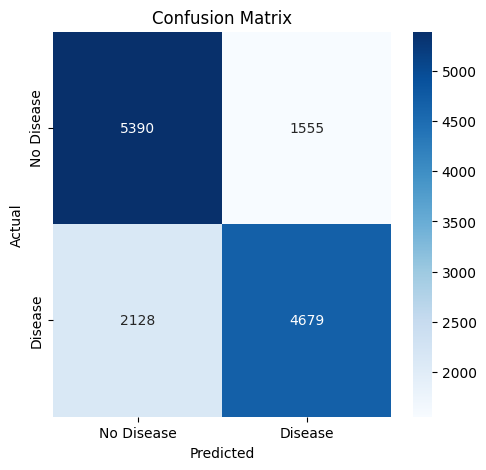

In [53]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')